### Faster R-CNN on Centers: Single Frames Only

The goal is to train the model separetely on each of the ceneters and have it predict on the center it trained on and the others so we can understand our metrics. The code will used dynamic augmentation.

Step 1: Load in Center Data and Generate JSON Files

In [ ]:
# USE IN GOOGLE DRIVE
#from google.colab import drive
#drive.mount('/content/drive')
from pathlib import Path
ROOT = Path("../data/center_stratified")

In [ ]:
import os, json, cv2, numpy as np
from pathlib import Path
from tqdm.auto import tqdm
import albumentations as A
from pathlib import Path
from PIL import Image
import json, re

In [ ]:
def yolo_to_coco(images_dir, labels_dir, out_json, class_name="polyp"):
    images_dir, labels_dir, out_json = Path(images_dir), Path(labels_dir), Path(out_json)
    img_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

    # index labels by normalized key
    label_index = {(p.stem): p for p in labels_dir.rglob("*.txt")}
    print(f"[diag] labels_dir={labels_dir} → {len(label_index)} txt files (keys look like: {list(label_index)[:3]})")

    images, annotations = [], []
    categories = [{"id": 1, "name": class_name}]
    ann_id, img_id = 1, 1
    matched, parsed, skipped = 0, 0, 0

    for img_path in sorted(p for p in images_dir.rglob("*") if p.suffix.lower() in img_exts):
        try:
            with Image.open(img_path) as im:
                W, H = im.size
        except Exception as e:
            print(f"[warn] failed to open {img_path}: {e}")
            continue

        images.append({
            "id": img_id,
            "file_name": str(img_path.resolve()),
            "width": W,
            "height": H
        })

        lf = label_index.get((img_path.stem))
        if lf and lf.exists():
            matched += 1
            with lf.open("r", encoding="utf-8", errors="ignore") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue

                    # try YOLO normalized: cls cx cy w h in [0,1]
                    ok = False
                    try:
                        cx, cy, w, h = map(float, parts[1:5])
                        if 0 <= cx <= 1 and 0 <= cy <= 1 and 0 <= w <= 1 and 0 <= h <= 1:
                            x = (cx - w/2) * W
                            y = (cy - h/2) * H
                            bw = w * W
                            bh = h * H
                            ok = True
                    except Exception:
                        ok = False

                    # fallback: pixels xyxy → COCO
                    if not ok:
                        try:
                            x1, y1, x2, y2 = map(float, parts[1:5])
                            if x2 > x1 and y2 > y1:
                                x = max(0.0, min(x1, W-1))
                                y = max(0.0, min(y1, H-1))
                                bw = max(0.0, min(x2, W-1) - x)
                                bh = max(0.0, min(y2, H-1) - y)
                                ok = (bw > 1 and bh > 1)
                        except Exception:
                            ok = False

                    if not ok:
                        skipped += 1
                        continue

                    annotations.append({
                        "id": ann_id,
                        "image_id": img_id,
                        "category_id": 1,
                        "bbox": [float(x), float(y), float(bw), float(bh)],
                        "area": float(bw * bh),
                        "iscrowd": 0
                    })
                    ann_id += 1
                    parsed += 1

        img_id += 1

    coco = {"images": images, "annotations": annotations, "categories": categories}
    out_json.parent.mkdir(parents=True, exist_ok=True)
    with out_json.open("w") as f:
        json.dump(coco, f)

    print(f"[diag] images_dir={images_dir}")
    print(f"[diag] matched images={matched}/{len(images)}  parsed boxes={parsed}  skipped lines={skipped}")
    print(f"Wrote {out_json} ({len(images)} images, {len(annotations)} boxes).")


In [4]:
# train annotations

#ROOT = Path("/content/drive/MyDrive/ErdosFall25/data/center_stratified")
#centers = ['C1', 'C2', 'C3', 'C4', 'C5']
centers = ['C1']

data_centers = {}

for c in centers:
    yolo_to_coco(
      images_dir = ROOT / f"{c}/images/train",
      labels_dir = ROOT / f"{c}/labels/train",
      out_json   = ROOT / f"{c}/{c}_annotations.json")


[diag] labels_dir=..\data\center_stratified\C1\labels\train → 204 txt files (keys look like: ['c1s000p1_50d1_419OLCV1_100H0014', 'c1s001p1_31d6_241OLCV1_100H0002', 'c1s002p1_12d1_177OLCV1_100H0038'])
[diag] images_dir=..\data\center_stratified\C1\images\train
[diag] matched images=204/204  parsed boxes=222  skipped lines=0
Wrote ..\data\center_stratified\C1\C1_annotations.json (204 images, 222 boxes).


In [5]:
# val annotations
#centers = ['C1', 'C2', 'C3', 'C4', 'C5']
centers = ['C1']

for c in centers:
    yolo_to_coco(
    images_dir = ROOT / f"{c}/images/val",
    labels_dir = ROOT / f"{c}/labels/val",
    out_json   = ROOT / f"{c}/{c}_annotations_val.json"
)

[diag] labels_dir=..\data\center_stratified\C1\labels\val → 26 txt files (keys look like: ['c1s000p1_21d1_372OLCV1_100H0016', 'c1s001p1_14d8_673OLCV1_100H0010', 'c1s002p1_2d84_718OLCV1_100H0002'])
[diag] images_dir=..\data\center_stratified\C1\images\val
[diag] matched images=26/26  parsed boxes=28  skipped lines=0
Wrote ..\data\center_stratified\C1\C1_annotations_val.json (26 images, 28 boxes).


Start Building Data

In [6]:
import json, cv2, torch, numpy as np
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [7]:
# Paths to all the annotations
centers = ['C1', 'C2', 'C3', 'C4', 'C5']

#ROOT = Path("/content/drive/MyDrive/ErdosFall25/data/center_stratified")

images_t = ROOT / "C1" / "images" / "train"
labels_t = ROOT / "C1" / "labels" / "train"
json_t   = ROOT / "C1" / "C1_annotations.json"

images_v = ROOT / "C1" / "images" / "val"
labels_v = ROOT / "C1" / "labels" / "val"
json_v   = ROOT / "C1" / "C1_annotations_val.json"


In [8]:
IMG_SIZE  = (640, 640)
NUM_CLASSES = 2
BATCH_SIZE = 2


In [9]:
def build_train_augs(img_h=640, img_w=640):
    return A.Compose(
        [
            # keep aspect ratio: scale longest side, then pad
            A.LongestMaxSize(max_size=max(img_h, img_w)),
            A.PadIfNeeded(min_height=img_h, min_width=img_w, border_mode=cv2.BORDER_CONSTANT),
            A.HorizontalFlip(p=0.5),

            # use Affine instead of ShiftScaleRotate
            A.Affine(
                scale=(0.9, 1.1),
                rotate=(-10, 10),
                translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
                cval=0,               # fill value for pixels introduced by transform
                cval_mask=0,
                mode=cv2.BORDER_CONSTANT,
                fit_output=False,
                p=0.5
            ),

            A.RandomBrightnessContrast(p=0.3),
            # Keep images in uint8; Faster R-CNN will see [0..1] after ToTensor in your Dataset
        ],
        bbox_params=A.BboxParams(
            format="pascal_voc",     # [x1,y1,x2,y2] in pixels
            label_fields=["labels"],
            min_visibility=0.2,      # drops heavily shrunken/occluded boxes
            min_area=4               # tiny specks get removed
        ),
    )

def build_val_augs(img_h=640, img_w=640):
    return A.Compose(
        [
            A.LongestMaxSize(max_size=max(img_h, img_w)),
            A.PadIfNeeded(min_height=img_h, min_width=img_w, border_mode=cv2.BORDER_CONSTANT),
        ],
        bbox_params=A.BboxParams(format="pascal_voc", label_fields=["labels"]),
    )

In [10]:
def coco_to_voc(anns):
    """COCO bbox [x,y,w,h] -> Pascal VOC [x1,y1,x2,y2]; also pull labels."""
    boxes, labels = [], []
    for a in anns:
        x, y, w, h = a["bbox"]
        x1, y1, x2, y2 = x, y, x + w, y + h
        # guard against negative/NaN
        if w <= 0 or h <= 0:
            continue
        boxes.append([x1, y1, x2, y2])
        labels.append(int(a["category_id"]))
    return boxes, labels

def clip_box_xyxy(box, w, h):
    x1, y1, x2, y2 = box
    x1 = np.clip(x1, 0, w - 1)
    y1 = np.clip(y1, 0, h - 1)
    x2 = np.clip(x2, 0, w - 1)
    y2 = np.clip(y2, 0, h - 1)
    # ensure valid ordering
    x1, x2 = min(x1, x2), max(x1, x2)
    y1, y2 = min(y1, y2), max(y1, y2)
    return [x1, y1, x2, y2]

def sanitize_targets(boxes, labels, img_w, img_h):
    if len(boxes) == 0:
        return [], []
    boxes = [clip_box_xyxy(b, img_w, img_h) for b in boxes]
    # drop zero-area after clip
    out_b, out_l = [], []
    for b, l in zip(boxes, labels):
        if (b[2] - b[0]) > 1 and (b[3] - b[1]) > 1:
            out_b.append(b); out_l.append(l)
    return out_b, out_l


In [11]:
from torchvision.datasets import CocoDetection
class CocoForFasterRCNN(CocoDetection):
    def __init__(self, img_root, ann_file, tfm=None):
        super().__init__(img_root, ann_file)
        self.tfm = tfm  # Albumentations compose or None

    def __getitem__(self, idx):
        img, anns = super().__getitem__(idx)  # PIL image, list of anns
        img = np.array(img.convert("RGB"))    # HWC uint8
        H, W = img.shape[:2]

        boxes, labels = coco_to_voc(anns)
        boxes, labels = sanitize_targets(boxes, labels, W, H)

        if self.tfm is not None:
            transformed = self.tfm(image=img, bboxes=boxes, labels=labels)
            img = transformed["image"]
            boxes = transformed["bboxes"]
            labels = transformed["labels"]
        else:
            # no augs: still need to convert to tensor
            img = TF.to_tensor(img)  # [C,H,W] float32 in [0,1]

        # Albumentations returns numpy arrays; convert if needed
        if isinstance(img, np.ndarray):
            # assume uint8 HWC; convert to [0..1] tensor
            img = TF.to_tensor(img)

        # finalize target
        if len(boxes) == 0:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)
        else:
            boxes_t = torch.tensor(boxes, dtype=torch.float32)
            labels_t = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([idx]),
        }
        return img, target

def collate_fn(batch):
    return tuple(zip(*batch))


In [12]:
train_tfm = build_train_augs(IMG_SIZE[0], IMG_SIZE[1])
val_tfm   = build_val_augs(IMG_SIZE[0], IMG_SIZE[1])

train_set = CocoForFasterRCNN(images_t, json_t, tfm=train_tfm)
val_set   = CocoForFasterRCNN(images_v,  json_v,  tfm=val_tfm)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True, collate_fn=collate_fn)


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


C:\Users\Betul\AppData\Local\Temp\ipykernel_15464\1908266591.py:10: UserWarning: Argument(s) 'cval, cval_mask, mode' are not valid for transform Affine
  A.Affine(


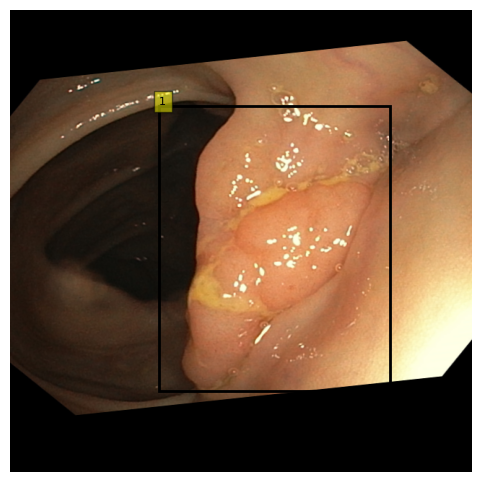

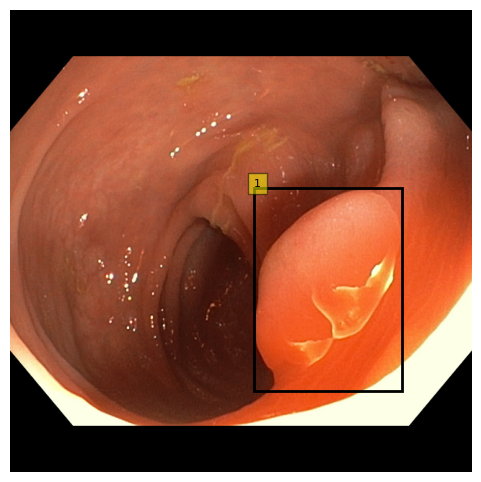

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision.transforms.functional as TF


def show_item(ds, i=0):
    img, tgt = ds[i]
    im = img.permute(1,2,0).numpy()
    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(im)
    for (x1,y1,x2,y2), lab in zip(tgt["boxes"].numpy(), tgt["labels"].numpy()):
        rect = patches.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, linewidth=2)
        ax.add_patch(rect)
        ax.text(x1, y1-2, str(lab), fontsize=8, bbox=dict(facecolor='yellow', alpha=0.5))
    ax.axis("off")
    plt.show()

show_item(train_set, 1)
show_item(val_set, 25)


In [14]:
import torch
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# num_classes = (background) + (# of categories in your train COCO)
cat_ids = train_set.coco.getCatIds()
num_classes = 1 + len(cat_ids)   # background is implicit class 0
print("num_classes:", num_classes, "cat_ids:", cat_ids)


num_classes: 2 cat_ids: [1]


In [15]:
model = fasterrcnn_resnet50_fpn_v2(weights="DEFAULT")  # pretrain on COCO helps
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       

In [16]:
import torch.optim as optim

params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=0.0005, momentum=0.9, weight_decay=1e-4)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

scaler = torch.amp.GradScaler(device.type if device.type != "cpu" else "cpu")


In [17]:
def train_one_epoch(model, loader):
    model.train()
    running = 0.0
    for imgs, targets in loader:
        imgs = [im.to(device) for im in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type=="cuda")):
            loss_dict = model(imgs, targets)
            loss = sum(loss_dict.values())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running += loss.item()
    return running / max(1, len(loader))


In [18]:
@torch.no_grad()
def evaluate_loss(model, loader):
    model.train(True)
    total = 0.0
    for imgs, targets in loader:
        imgs = [im.to(device) for im in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        with torch.amp.autocast(device_type=device.type, enabled=(device.type=="cuda")):
            loss_dict = model(imgs, targets)
            loss = sum(loss_dict.values())
        total += loss.item()
    return total / max(1, len(loader))

# quick smoke test forward
imgs, targets = next(iter(train_loader))
_ = model([i.to(device) for i in imgs], [{k:v.to(device) for k,v in t.items()} for t in targets])
print("forward pass OK")

forward pass OK


In [19]:
""""
EPOCHS = 20
for epoch in range(EPOCHS):
    tr = train_one_epoch(model, train_loader)
    vl = evaluate_loss(model, val_loader)
    lr_scheduler.step()
    print(f"epoch {epoch+1:02d} | train_loss={tr:.4f} | val_loss={vl:.4f}")
"""  

'"\nEPOCHS = 20\nfor epoch in range(EPOCHS):\n    tr = train_one_epoch(model, train_loader)\n    vl = evaluate_loss(model, val_loader)\n    lr_scheduler.step()\n    print(f"epoch {epoch+1:02d} | train_loss={tr:.4f} | val_loss={vl:.4f}")\n'

In [20]:
""""
ckpt_path = "model_15_epoch"
# --- save checkpoint ---
torch.save({
    "epoch": epoch,
    "model": model.state_dict(),
}, ckpt_path)
print("Saved", ckpt_path)
"""

'"\nckpt_path = "model_15_epoch"\n# --- save checkpoint ---\ntorch.save({\n    "epoch": epoch,\n    "model": model.state_dict(),\n}, ckpt_path)\nprint("Saved", ckpt_path)\n'

In [21]:
# 2️⃣ Load the saved weights
ckpt_path = "model_15_epoch"  # your checkpoint filename
checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model"])
print(f"Loaded model weights from {ckpt_path}")

C:\Users\Betul\AppData\Local\Temp\ipykernel_15464\1951359125.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location=device)


Loaded model weights from model_15_epoch


In [22]:
import torch
from pathlib import Path
from torchvision.ops import nms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

all_preds = []  # one dict per image

score_thresh = 0.05
iou_thresh = 0.5  # for optional NMS
save_json = "detections_val.json"

@torch.no_grad()
def run_inference_detection():
    for images, targets in val_loader:
        # Move to device
        images = [img.to(device) for img in images]

        # Inference
        outputs = model(images)  # list of dicts: boxes, labels, scores, (masks optional)

        # Per-image postprocessing and collection
        for i, out in enumerate(outputs):
            boxes  = out["boxes"]   # (N, 4) xyxy
            scores = out["scores"]  # (N,)
            labels = out["labels"]  # (N,)

            # Filter by confidence
            keep = scores >= score_thresh
            boxes, scores, labels = boxes[keep], scores[keep], labels[keep]

            # Optional: NMS
            if boxes.numel() > 0:
                keep2 = nms(boxes, scores, iou_thresh)
                boxes, scores, labels = boxes[keep2], scores[keep2], labels[keep2]

            image_id = None
            if isinstance(targets, (list, tuple)) and "image_id" in targets[i]:
                image_id = int(targets[i]["image_id"])
            else:
                image_id = None  # or use your own filename logic

            all_preds.append({
                "image_id": image_id,
                "boxes": boxes.detach().cpu().tolist(),   # [[x1,y1,x2,y2], ...]
                "scores": scores.detach().cpu().tolist(),
                "labels": labels.detach().cpu().tolist(),
            })

    return all_preds

preds = run_inference_detection()

# (Optional) Save to JSON for later analysis / mAP eval
import json
with open(save_json, "w") as f:
    json.dump(preds, f)
print(f"Saved {len(preds)} image predictions to {save_json}")


Saved 26 image predictions to detections_val.json


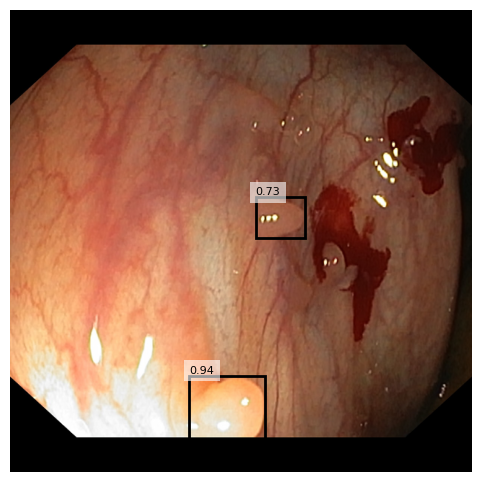

In [26]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cv2

model.eval()
with torch.no_grad():
    for imgs, targets in val_loader:
        img = imgs[0].to(device)
        out = model([img])[0]
        im_np = (img.permute(1,2,0).cpu().numpy()*255).clip(0,255).astype("uint8")

    plt.figure(figsize=(6,6))
    plt.imshow(im_np)
    ax = plt.gca()
    for (x1,y1,x2,y2), s in zip(out["boxes"].cpu(), out["scores"].cpu()):
        if s < 0.5: continue
        ax.add_patch(Rectangle((x1,y1), x2-x1, y2-y1, fill=False, linewidth=2))
        ax.text(x1, max(0,y1-3), f"{s:.2f}", fontsize=8, bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    ax.set_axis_off()
    plt.show()

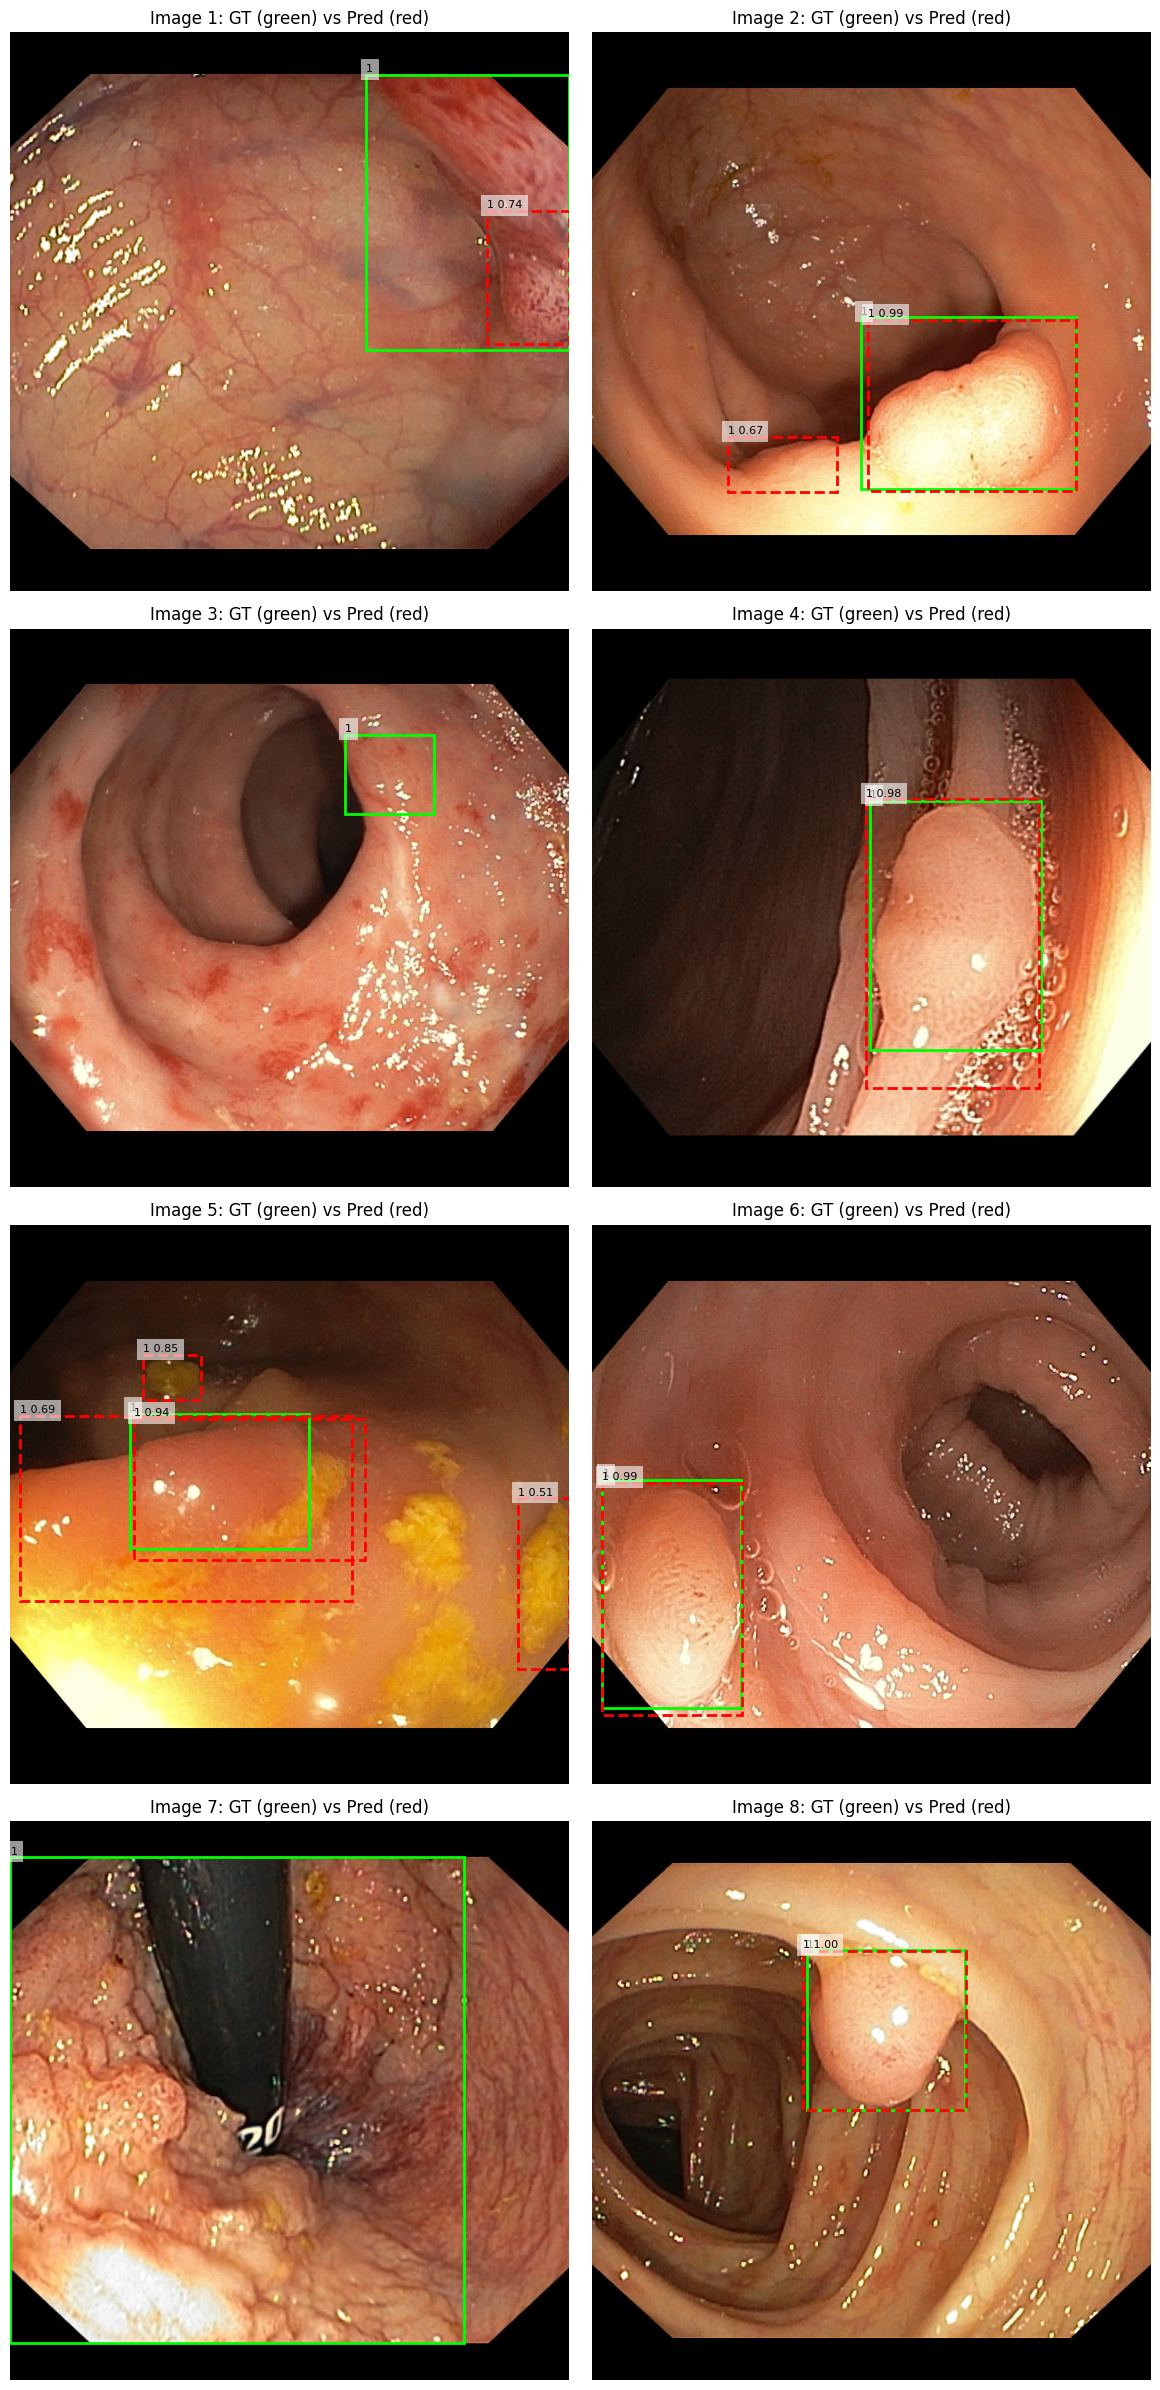

In [27]:
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from typing import Optional, List

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device).eval()

# ---- Config ----
SCORE_THRESH = 0.5
MAX_IMAGES   = 8     # how many images from val_loader to visualize
COLS         = 2     # subplot columns
# If your dataset uses normalization, set these; otherwise leave None
IMAGENET_MEAN = None  # e.g., [0.485, 0.456, 0.406]
IMAGENET_STD  = None  # e.g., [0.229, 0.224, 0.225]

def _to_uint8_hwc(img: torch.Tensor,
                  mean: Optional[List[float]] = None,
                  std: Optional[List[float]] = None) -> "np.ndarray":
    """
    img: Tensor [C,H,W], values typically in [0,1] or normalized.
    Returns uint8 HWC numpy image.
    """
    t = img.detach().clone()
    if std is not None and mean is not None:
        mean_t = torch.tensor(mean, device=t.device).view(3,1,1)
        std_t  = torch.tensor(std,  device=t.device).view(3,1,1)
        t = (t * std_t + mean_t).clamp(0,1)
    else:
        t = t.clamp(0,1)
    return (t.mul(255).byte().permute(1,2,0).cpu().numpy())

def _draw_boxes(ax, boxes, color="red", lw=2, ls="-", label_texts=None):
    """
    boxes: Tensor/ndarray Nx4 in xyxy
    label_texts: list of strings (same length as boxes) to draw above boxes
    """
    if boxes is None or len(boxes) == 0:
        return
    boxes = boxes.detach().cpu().numpy() if hasattr(boxes, "detach") else boxes
    for i, (x1, y1, x2, y2) in enumerate(boxes):
        rect = Rectangle((float(x1), float(y1)),
                         float(x2 - x1), float(y2 - y1),
                         fill=False, edgecolor=color, linewidth=lw, linestyle=ls)
        ax.add_patch(rect)
        if label_texts and i < len(label_texts) and label_texts[i] is not None:
            ax.text(float(x1), max(0.0, float(y1) - 3.0),
                    label_texts[i],
                    fontsize=8,
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'),
                    color="black")

@torch.no_grad()
def visualize_gt_vs_pred(val_loader,
                         max_images: int = MAX_IMAGES,
                         cols: int = COLS,
                         score_thresh: float = SCORE_THRESH,
                         class_names: Optional[List[str]] = None):
    """
    Shows a grid of images with GT (green) vs Pred (red, dashed).
    If class_names provided, uses them for labels; otherwise shows class id.
    """
    shown = 0
    rows = (max_images + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 6*rows))
    if rows * cols == 1:
        axes = [axes]  # make iterable
    axes = axes.flatten() if isinstance(axes, (list, tuple)) else axes.ravel()

    for imgs, targets in val_loader:
        # TorchVision detection datasets usually yield lists
        if isinstance(imgs, torch.Tensor):  # fallback: a batch tensor [B,C,H,W]
            imgs = [imgs[i] for i in range(imgs.shape[0])]
        if isinstance(targets, dict):  # fallback: single dict
            targets = [targets]

        for i in range(len(imgs)):
            if shown >= max_images:
                break

            img = imgs[i].to(device)
            out = model([img])[0]  # dict with "boxes","scores","labels", etc.

            # Prepare image for plotting
            im_np = _to_uint8_hwc(img, mean=IMAGENET_MEAN, std=IMAGENET_STD)

            ax = axes[shown]
            ax.imshow(im_np)
            ax.set_axis_off()
            ax.set_title(f"Image {shown+1}: GT (green) vs Pred (red)")

            # Ground truth
            if targets is not None and len(targets) > i and "boxes" in targets[i]:
                gt_boxes = targets[i]["boxes"]
                gt_labels = targets[i].get("labels", None)
                if gt_labels is not None:
                    gt_labels = gt_labels.detach().cpu().tolist()
                    gt_texts = [class_names[c] if (class_names and c < len(class_names)) else str(c)
                                for c in gt_labels]
                else:
                    gt_texts = None
                _draw_boxes(ax, gt_boxes, color="lime", lw=2, ls="-", label_texts=gt_texts)

            # Predictions (filter by score)
            pred_boxes  = out.get("boxes", None)
            pred_scores = out.get("scores", None)
            pred_labels = out.get("labels", None)

            if pred_boxes is not None and pred_scores is not None:
                keep = pred_scores >= score_thresh
                pred_boxes  = pred_boxes[keep]
                pred_scores = pred_scores[keep]
                if pred_labels is not None:
                    pred_labels = pred_labels[keep].detach().cpu().tolist()
                    pred_texts = []
                    for j, c in enumerate(pred_labels):
                        cname = class_names[c] if (class_names and c < len(class_names)) else str(c)
                        pred_texts.append(f"{cname} {float(pred_scores[j]):.2f}")
                else:
                    pred_texts = [f"{float(s):.2f}" for s in pred_scores.detach().cpu().tolist()]

                _draw_boxes(ax, pred_boxes, color="red", lw=2, ls="--", label_texts=pred_texts)

            shown += 1

        if shown >= max_images:
            break

    # If we didn’t fill the grid, hide extras
    for k in range(shown, len(axes)):
        axes[k].axis("off")

    plt.tight_layout()
    plt.show()

# ---- Run it ----
visualize_gt_vs_pred(val_loader, max_images=8, cols=2, score_thresh=0.5, class_names=None)
